<a href="https://colab.research.google.com/github/FranciscoRMendes/coastline-paradox-3d/blob/main/coastline_paradox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coastline Paradox — Python Notebook

This notebook demonstrates the **coastline paradox** — the mathematical phenomenon where measured length or area depends on the resolution of measurement. We progress from 1D to 3D and from synthetic to real geographic data:

1. **2D Coastline Paradox** — Koch curve ruler method
2. **3D Surface Area Paradox** — synthetic fractal terrain (diamond-square algorithm)
3. **Real Geographic Data** — Telegraph Hill DEM, San Francisco
4. **Fractal Dimension** — quantifying roughness via log-log scaling

See the [blog post](https://franciscormendes.github.io/2025/12/16/3d-coastline-paradox/) for the full write-up.

## 1. 2D Coastline Paradox (Koch Curve)

We use the **Koch curve** — a classic self-similar fractal — to show that measured length grows without bound as the ruler size shrinks. The key relation is:

$$L(\varepsilon) \sim \varepsilon^{1-D_1}, \quad D_1 = 1 - \frac{d\log L}{d\log \varepsilon}$$

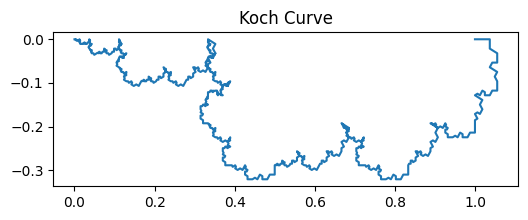

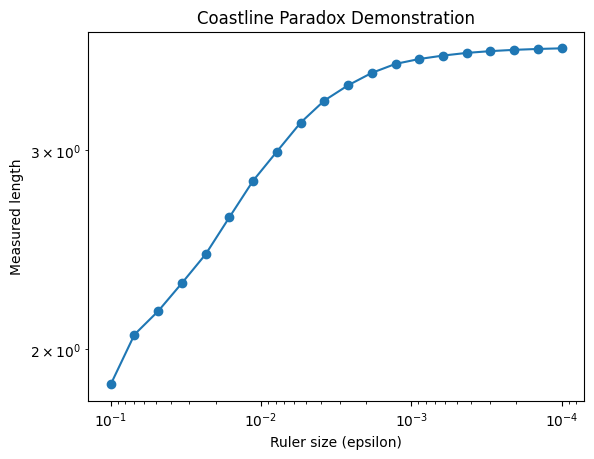

In [30]:
import math
import numpy as np
import matplotlib.pyplot as plt
# import ipympl

# Function to resample a line at a given step size
def resample_line(points, step):
    points = np.asarray(points)
    if points.shape[0] < 2:
        return points
    # Calculate segments and their lengths
    segs = points[1:] - points[:-1]
    dists = np.hypot(segs[:,0], segs[:,1])
    cum = np.concatenate([[0.0], np.cumsum(dists)])
    total = cum[-1]
    if total == 0:
        return points
    # Determine number of steps and sample locations
    n_steps = max(2, int(math.floor(total / step)) + 1)
    sample_locs = np.linspace(0, total, n_steps)
    # Interpolate x and y coordinates at new sample locations
    xs = np.interp(sample_locs, cum, points[:,0])
    ys = np.interp(sample_locs, cum, points[:,1])
    return np.vstack([xs, ys]).T

# Function to measure the length of a line using a given ruler step
def ruler_length(points, step):
    # Resample the line and sum the lengths of the new segments
    sampled = resample_line(points, step)
    segs = sampled[1:] - sampled[:-1]
    return float(np.sum(np.hypot(segs[:,0], segs[:,1])))

# Function to generate a Koch curve
def koch_curve(iterations=4):
    pts = [(0.0, 0.0), (1.0, 0.0)]
    def subdivide(pts):
        new_pts = []
        for a,b in zip(pts[:-1], pts[1:]):
            ax,ay = a; bx,by = b
            vx = (bx-ax); vy = (by-ay)
            p1 = (ax,ay)
            p2 = (ax + vx/3.0, ay + vy/3.0)
            p4 = (ax + 2.0*vx/3.0, ay + 2.0*vy/3.0)
            p5 = (bx,by)
            angle = math.atan2(vy, vx) - math.pi/3.0
            length = math.hypot(vx, vy)/3.0
            p3 = (p2[0] + math.cos(angle)*length, p2[1] + math.sin(angle)*length)
            new_pts.extend([p1, p2, p3])
        new_pts.append(pts[-1])
        return new_pts
    # Apply subdivision for the specified number of iterations
    for i in range(iterations):
        pts = subdivide(pts)
    return np.array(pts)

# Generate a Koch curve with 6 iterations
koch = koch_curve(iterations=6)
# Plot the Koch curve
plt.figure(figsize=(6,2))
plt.plot(koch[:,0], koch[:,1])
plt.title("Koch Curve")
plt.show()

# Measure the length of the Koch curve at multiple ruler scales
steps = np.logspace(-4, -1, 20)
lengths = [ruler_length(koch, s) for s in steps]

# Plot the measured length vs. ruler size (coastline paradox demonstration)
plt.loglog(steps, lengths, "-o")
plt.gca().invert_xaxis() # Invert x-axis to show smaller ruler sizes on the right
plt.xlabel("Ruler size (epsilon)")
plt.ylabel("Measured length")
plt.title("Coastline Paradox Demonstration")
plt.show()

## 2. 3D Surface Area Paradox (Synthetic Terrain)

We extend the paradox to surfaces using the **diamond-square algorithm**, which generates realistic fractal terrain. The area analogue of the coastline relation is:

$$A(\varepsilon) \sim \varepsilon^{2-D_2}, \quad D_2 = 2 - \frac{d\log A}{d\log \varepsilon}, \quad 2 < D_2 < 3$$

In [ ]:
np.random.seed(42)  # For reproducibility

def diamond_square(size=129, roughness=0.5):
    """
    Generate a fractal terrain using the diamond-square algorithm.
    size must be 2^n + 1 (e.g. 129 = 2^7 + 1).
    roughness controls height variation at each subdivision step.
    """
    grid = np.zeros((size, size), dtype=float)
    grid[0, 0]   = np.random.rand()
    grid[0, -1]  = np.random.rand()
    grid[-1, 0]  = np.random.rand()
    grid[-1, -1] = np.random.rand()

    step_size = size - 1
    scale = roughness

    while step_size > 1:
        half = step_size // 2

        # Diamond step: set midpoint of each square
        for x in range(0, size - 1, step_size):
            for y in range(0, size - 1, step_size):
                avg = (grid[x, y] + grid[x + step_size, y] +
                       grid[x, y + step_size] + grid[x + step_size, y + step_size]) / 4.0
                grid[x + half, y + half] = avg + np.random.uniform(-scale, scale)

        # Square step: set midpoint of each diamond edge
        for x in range(0, size, half):
            for y in range((x + half) % step_size, size, step_size):
                neighbors = []
                if x - half >= 0:   neighbors.append(grid[x - half, y])
                if x + half < size: neighbors.append(grid[x + half, y])
                if y - half >= 0:   neighbors.append(grid[x, y - half])
                if y + half < size: neighbors.append(grid[x, y + half])
                grid[x, y] = np.mean(neighbors) + np.random.uniform(-scale, scale)

        step_size //= 2
        scale *= roughness

    return grid


surface = diamond_square(size=129, roughness=0.5)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(np.arange(surface.shape[0]), np.arange(surface.shape[1]))
ax.plot_surface(X, Y, surface, cmap='terrain', edgecolor='none')
ax.set_title('Fractal Surface (Diamond-Square Algorithm)')
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_zlabel('Elevation (a.u.)')
plt.show()

In [ ]:
def tri_area(tri):
    """Compute the area of a 3D triangle using Heron's formula."""
    a = np.linalg.norm(tri[0] - tri[1])
    b = np.linalg.norm(tri[1] - tri[2])
    c = np.linalg.norm(tri[2] - tri[0])
    s = (a + b + c) / 2
    return np.sqrt(max(s * (s - a) * (s - b) * (s - c), 0.0))


def surface_area_approx_pixels(surface, step=1):
    """
    Approximate surface area for a synthetic surface.
    Each step×step square is divided into two triangles.
    x, y, and z must all be in the same units for geometrically correct results.
    """
    area = 0.0
    n, m = surface.shape
    for i in range(0, n - 1, step):
        for j in range(0, m - 1, step):
            z00 = surface[i, j]
            z10 = surface[min(i + step, n - 1), j]
            z01 = surface[i, min(j + step, m - 1)]
            z11 = surface[min(i + step, n - 1), min(j + step, m - 1)]

            tri1 = np.array([[0, 0, z00], [step, 0, z10], [step, step, z11]], dtype=float)
            tri2 = np.array([[0, 0, z00], [step, step, z11], [0, step, z01]], dtype=float)
            area += tri_area(tri1) + tri_area(tri2)
    return area

In [ ]:
# Normalize surface height to match pixel scale so the fractal dimension
# reflects genuine roughness. Without this, z ∈ [0,~2] vs x/y ∈ [0,128]
# makes the terrain essentially flat, giving D ≈ 2 trivially.
surface_size = surface.shape[0] - 1  # 128 pixels
surface_norm = (surface - surface.min()) / (surface.max() - surface.min()) * surface_size

steps3d = [64, 32, 16, 8, 4, 2]  # ruler sizes in pixels
areas3d = [surface_area_approx_pixels(surface_norm, s) for s in steps3d]

plt.figure(figsize=(6, 4))
plt.plot(steps3d, areas3d, '-o')
plt.gca().invert_xaxis()
plt.xlabel("Ruler size (pixels)")
plt.ylabel("Measured surface area (pixels²)")
plt.title("3D Coastline Paradox — Synthetic Terrain")
plt.grid(True)
plt.show()

## 3. Real Geographic Data — Telegraph Hill, San Francisco

We replace the synthetic terrain with a real **USGS Digital Elevation Model (DEM)** of Telegraph Hill (500 m × 500 m at 0.25 m/pixel). The same surface area measurement is applied at ruler sizes of 256, 128, 64, and 32 m.

In [ ]:
def surface_area_approx(surface, step_meters, cell_size):
    """
    Approximate surface area for a geographic DEM.
    Uses physical meter coordinates for x, y, and z so triangle areas are
    geometrically correct regardless of terrain slope. Returns area in meters².

    The previous approach of using pixel x/y with meter z and then scaling
    by cell_size² is incorrect because the cross-terms (e.g. pixel × meters)
    produce wrong 3D distances. Using meters throughout avoids this.
    """
    step = max(1, int(round(step_meters / cell_size)))  # ruler size in pixels
    step_m = step * cell_size                           # ruler size in meters
    area = 0.0
    n, m = surface.shape
    for i in range(0, n - 1, step):
        for j in range(0, m - 1, step):
            z00 = surface[i, j]
            z10 = surface[min(i + step, n - 1), j]
            z01 = surface[i, min(j + step, m - 1)]
            z11 = surface[min(i + step, n - 1), min(j + step, m - 1)]

            # All coordinates in meters — geometrically correct 3D triangles
            tri1 = np.array([[0, 0, z00], [step_m, 0, z10], [step_m, step_m, z11]], dtype=float)
            tri2 = np.array([[0, 0, z00], [step_m, step_m, z11], [0, step_m, z01]], dtype=float)
            area += tri_area(tri1) + tri_area(tri2)
    return area  # meters²

In [36]:
import os
import rasterio

# List files (optional)
print(os.listdir())

# Open DEM
ds = rasterio.open("USGS_OPR_CA_SanFrancisco_B23_05150295.tif")

# Extract pixel size
pixel_width = ds.transform.a
pixel_height = abs(ds.transform.e)

# For square pixels, cell size is the same in x and y
cell_size = (pixel_width + pixel_height) / 2

print("DEM cell size (meters):", cell_size)


['.config', 'dem_and_telegraph_hill_map.html', 'USGS_OPR_CA_SanFrancisco_B23_05150295.tif', 'sample_data']
DEM cell size (meters): 0.25


In [37]:
# Get bounds
bounds = ds.bounds  # returns left, bottom, right, top in the CRS of the raster

print("Bounds in CRS units:", bounds)

# If the raster is in a projected CRS (e.g., UTM), convert to lat/lon
from pyproj import Transformer

# Create transformer from raster CRS to WGS84 (lat/lon)
transformer = Transformer.from_crs(ds.crs, "EPSG:4326", always_xy=True)

# Transform corner coordinates
min_lon, min_lat = transformer.transform(bounds.left, bounds.bottom)
max_lon, max_lat = transformer.transform(bounds.right, bounds.top)

print("Bounding box (lat/lon):")
print("Min lat:", min_lat, "Min lon:", min_lon)
print("Max lat:", max_lat, "Max lon:", max_lon)

Bounds in CRS units: BoundingBox(left=51500.0, bottom=29500.0, right=52000.0, top=30000.0)
Bounding box (lat/lon):
Min lat: 37.79954597372846 Min lon: -122.410259615752
Max lat: 37.804048688549365 Max lon: -122.40457966103305


In [38]:
# Telegraph Hill coordinates in lat/lon
telegraph_lat, telegraph_lon = 37.8027, -122.4058

# Transformer from WGS84 (lat/lon) to DEM CRS
transformer = Transformer.from_crs("EPSG:4326", ds.crs, always_xy=True)

# Transform lat/lon to DEM CRS
x, y = transformer.transform(telegraph_lon, telegraph_lat)

print("Telegraph Hill in DEM CRS units:")
print("X:", x, "Y:", y)

Telegraph Hill in DEM CRS units:
X: 51892.60007344497 Y: 29850.25275731716


In [39]:
import folium

# DEM bounding box coordinates
# min_lat, min_lon = 37.75448514047917, -122.5180850315112
# max_lat, max_lon = 37.758993081397215, -122.51241506661886

# Telegraph Hill coordinates
telegraph_lat, telegraph_lon = 37.8027, -122.4058

# Compute center for map view
center_lat = (min_lat + max_lat + telegraph_lat) / 3
center_lon = (min_lon + max_lon + telegraph_lon) / 3

# Create map
m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

# Add DEM bounding box
folium.Rectangle(
    bounds=[[min_lat, min_lon], [max_lat, max_lon]],
    color='red',
    fill=True,
    fill_opacity=0.2,
    tooltip="DEM Tile"
).add_to(m)

# Add Telegraph Hill marker
folium.Marker(
    location=[telegraph_lat, telegraph_lon],
    popup="Telegraph Hill",
    icon=folium.Icon(color='blue', icon='info-sign')
).add_to(m)

# Save or display map
m.save("dem_and_telegraph_hill_map.html")
m  # if using Jupyter, this will display the interactive map


In [40]:
elev = ds.read(1)               # 2D array of elevation (Z)
# mask = elev == ds.nodata_value  # mask invalid data

# 2. Optionally crop to bounding box around Telegraph Hill
#    (use lat/lon bounds to index the raster window)

# 3. Convert to 3D surface geometry (X, Y grid + Z = elev)
xx, yy = np.meshgrid(np.arange(elev.shape[1]), np.arange(elev.shape[0]))
zz = elev.copy()


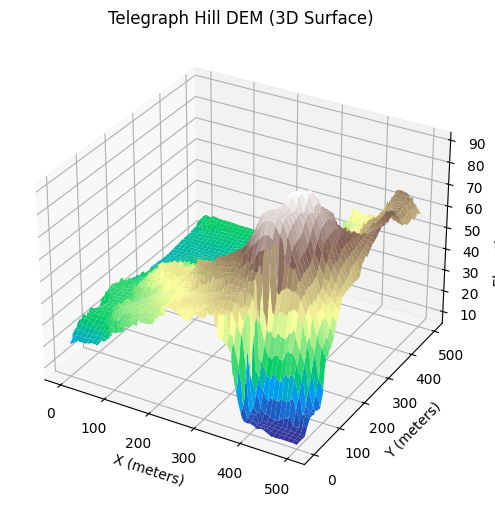

In [41]:
# Pixel size (meters)
dx = ds.transform.a
dy = abs(ds.transform.e)

# Create real-world X,Y grid (meters)
ny, nx = elev.shape
x = np.arange(nx) * dx
y = np.arange(ny) * dy
xx, yy = np.meshgrid(x, y)

zz = elev

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    xx, yy, zz,
    cmap="terrain",
    linewidth=0,
    antialiased=True
)

ax.set_title("Telegraph Hill DEM (3D Surface)")
ax.set_xlabel("X (meters)")
ax.set_ylabel("Y (meters)")
ax.set_zlabel("Elevation (meters)")

plt.show()

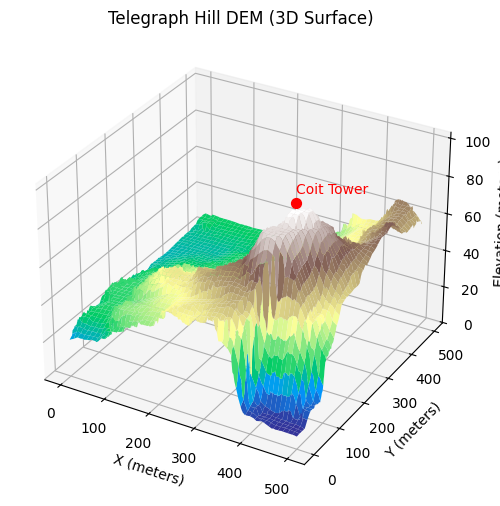

In [42]:
from pyproj import Transformer

# Example: Coit Tower WGS84 coordinates
lat_coit = 37.8024
lon_coit = -122.4058

# Create transformer from WGS84 to DEM CRS
transformer = Transformer.from_crs("EPSG:4326", ds.crs, always_xy=True)
x_proj, y_proj = transformer.transform(lon_coit, lat_coit)

from rasterio.transform import rowcol

row, col = rowcol(ds.transform, x_proj, y_proj)

z_coit = zz[row, col]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx, yy, zz, cmap="terrain", linewidth=0, antialiased=True)

# Mark Coit Tower
ax.scatter(col*dx, row*dy, z_coit + 5, color='red', s=50)
ax.text(col*dx, row*dy, z_coit + 10, "Coit Tower", color='red')

ax.set_title("Telegraph Hill DEM (3D Surface)")
ax.set_xlabel("X (meters)")
ax.set_ylabel("Y (meters)")
ax.set_zlabel("Elevation (meters)")
plt.show()


In [ ]:
th_ruler_steps_meters = [256, 128, 64, 32]  # ruler sizes in meters
th_areas = [surface_area_approx(zz, s, cell_size) for s in th_ruler_steps_meters]

plt.figure(figsize=(6, 4))
plt.plot(th_ruler_steps_meters, th_areas, '-o')
plt.gca().invert_xaxis()
plt.xlabel("Ruler size (meters)")
plt.ylabel("Measured surface area (m²)")
plt.title("Coastline Paradox for Telegraph Hill")
plt.grid(True)
plt.show()

## 4. Fractal Dimension Analysis

We fit a line to each log-log plot to extract the **Minkowski–Bouligand (box-counting) dimension** — the scale-invariant descriptor of roughness that remains constant regardless of measurement resolution.

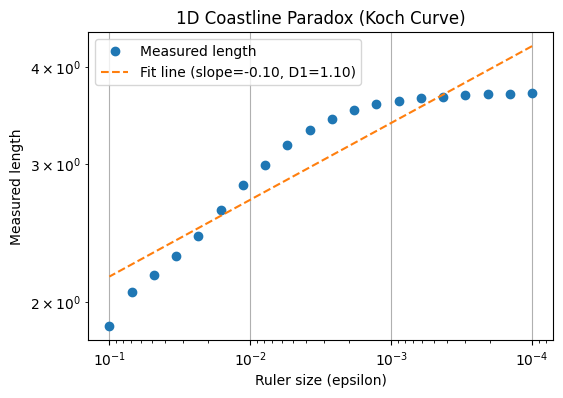

Estimated 1D fractal dimension D1 = 1.098
0.5402992039379554


In [44]:
from scipy.stats import linregress
steps = np.logspace(-4, -1, 20)
lengths = [ruler_length(koch, s) for s in steps]

# Log-log transform
log_eps = np.log(steps)
log_len = np.log(lengths)

# Linear fit to get slope
slope, intercept, r_value, p_value, std_err = linregress(log_eps, log_len)
D1 = 1 - slope  # Fractal dimension

# Plot
plt.figure(figsize=(6,4))
plt.loglog(steps, lengths, 'o', label='Measured length')
plt.loglog(steps, np.exp(intercept) * steps**slope, '--', label=f'Fit line (slope={slope:.2f}, D1={D1:.2f})')
plt.gca().invert_xaxis()
plt.xlabel("Ruler size (epsilon)")
plt.ylabel("Measured length")
plt.title("1D Coastline Paradox (Koch Curve)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Estimated 1D fractal dimension D1 = {D1:.3f}")
print(intercept)

In [ ]:
from scipy.stats import linregress

# Log-log transform
log_steps3D = np.log(steps3d)
log_areas3D = np.log(areas3d)

# Linear fit: A(ε) ~ ε^(2-D)  →  D = 2 - slope
slope3D, intercept3D, r_value3D, *_ = linregress(log_steps3D, log_areas3D)
D3 = 2 - slope3D

plt.figure(figsize=(6, 4))
plt.loglog(steps3d, areas3d, 'o', label='Measured area')
plt.loglog(steps3d, np.exp(intercept3D) * np.array(steps3d)**slope3D, '--',
           label=f'Fit (slope={slope3D:.3f}, D={D3:.4f})')
plt.gca().invert_xaxis()
plt.xlabel("Ruler size (pixels)")
plt.ylabel("Measured surface area (pixels²)")
plt.title("3D Coastline Paradox — Synthetic Terrain (Log-Log)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Estimated fractal dimension D = {D3:.4f}")

In [ ]:
from scipy.stats import linregress

# Log-log transform for Telegraph Hill
log_th_steps = np.log(th_ruler_steps_meters)
log_th_areas = np.log(th_areas)

# Linear fit: A(ε) ~ ε^(2-D)  →  D = 2 - slope
slope_th, intercept_th, r_value_th, *_ = linregress(log_th_steps, log_th_areas)
D_th = 2 - slope_th

plt.figure(figsize=(6, 4))
plt.loglog(th_ruler_steps_meters, th_areas, 'o', label='Measured area')
plt.loglog(th_ruler_steps_meters,
           np.exp(intercept_th) * np.array(th_ruler_steps_meters)**slope_th, '--',
           label=f'Fit (slope={slope_th:.3f}, D={D_th:.4f})')
plt.gca().invert_xaxis()
plt.xlabel("Ruler size (meters)")
plt.ylabel("Measured surface area (m²)")
plt.title("Coastline Paradox for Telegraph Hill (Log-Log)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Estimated fractal dimension D_TH = {D_th:.5f}")